In [ ]:

import os
import json
import random
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from openai import OpenAI


client = OpenAI(api_key="faefaf")
MODEL_NAME = "gpt-4.1-mini"

# Reproducibility for sampling
random.seed(42)


In [ ]:
# Path to your uploaded Yelp CSV
csv_path = "yelp.csv"

df = pd.read_csv(csv_path)


df = df[["stars", "text"]].dropna()

# Ensure 'stars' is integer
df["stars"] = df["stars"].astype(int)

# Sample 200 rows
N_SAMPLES = 200
if len(df) > N_SAMPLES:
    df_sample = df.sample(N_SAMPLES, random_state=42).reset_index(drop=True)
else:
    df_sample = df.copy().reset_index(drop=True)

print(df_sample.head())
print("Number of rows used:", len(df_sample))
df_sample.to_csv("yelp_200_clean.csv", index=False)


   stars                                               text
0      4  We got here around midnight last Friday... the...
1      5  Brought a friend from Louisiana here.  She say...
2      3  Every friday, my dad and I eat here. We order ...
3      1  My husband and I were really, really disappoin...
4      5  Love this place!  Was in phoenix 3 weeks for w...
Number of rows used: 200


In [ ]:
def call_llm_openai(prompt: str,
                    model: str = MODEL_NAME,
                    temperature: float = 0.2,
                    max_tokens: int = 200) -> str:
    """
    Call the OpenAI chat completion API and return the raw text response.
    """
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        max_completion_tokens=max_tokens,
    )
    return response.choices[0].message.content


def parse_json_response(raw_response: str):
    """
    Try to parse the model response as JSON.
    Returns:
        (predicted_stars (int or None), explanation (str or None), is_valid_json (bool))
    """
    try:
        raw = raw_response.strip()

        # Handle markdown-style ```json ... ``` wrappers
        if "```" in raw:
            parts = raw.split("```")
            json_candidate = None
            for p in parts:
                if "{" in p and "}" in p:
                    json_candidate = p[p.find("{"): p.rfind("}") + 1]
                    break
            if json_candidate is not None:
                raw = json_candidate

        data = json.loads(raw)

        predicted_stars = data.get("predicted_stars", None)
        explanation = data.get("explanation", None)

        # Normalize predicted_stars to int
        if isinstance(predicted_stars, (float, str)):
            try:
                predicted_stars = int(predicted_stars)
            except ValueError:
                return None, explanation, False

        if not isinstance(predicted_stars, int):
            return None, explanation, False

        if predicted_stars < 1 or predicted_stars > 5:
            return None, explanation, False

        return predicted_stars, explanation, True

    except Exception:
        return None, None, False


In [ ]:
def prompt_v1(review_text: str) -> str:
    """
    Version 1 — Basic Sentiment Prompt (Baseline)
    """
    return f"""
Read the following Yelp review and classify its rating from 1 to 5 stars.
Output valid JSON only.

Review:
\"\"\"{review_text}\"\"\"


JSON format:
{{
  "predicted_stars": <number from 1 to 5>,
  "explanation": "Brief reason"
}}
""".strip()


def prompt_v2(review_text: str) -> str:
    """
    Version 2 — Strict Format + Constraints
    """
    return f"""
Classify the rating of the following Yelp review from 1 to 5 stars.
Use only the text provided.

Rules:
- Output must be valid JSON.
- "predicted_stars" must be an integer from 1 to 5.
- Include only the two required keys: "predicted_stars" and "explanation".
- Do not add any extra text before or after the JSON.

Review:
\"\"\"{review_text}\"\"\"


Respond in exactly this format:
{{
  "predicted_stars": <1-5>,
  "explanation": "Explain using evidence from the review."
}}
""".strip()


def prompt_v3(review_text: str) -> str:
    """
    Version 3 — Rating Rubric + Few-Shot Examples
    """
    return f"""
You are a Yelp rating classifier.

Use this rubric:
1 star: Very negative, strong complaints, regretful visit.
2 stars: Mostly negative, multiple issues, little satisfaction.
3 stars: Mixed, average, both pros and cons.
4 stars: Mostly positive, minor issues only.
5 stars: Very positive, enthusiastic satisfaction.

Examples:
Review: "Amazing food! Will come again!"
Rating: 5

Review: "Terrible service, food was cold."
Rating: 1

Now classify the following review:

\"\"\"{review_text}\"\"\"


Output valid JSON in this structure:
{{
  "predicted_stars": <1-5>,
  "explanation": "Clear evidence for the rating."
}}
""".strip()


def prompt_v4(review_text: str) -> str:
    """
    Version 4 — Step-Based Scoring (Chain-of-Thought Style)
    """
    return f"""
Analyze the review using a 3-step process:

1) Sentiment score from 1 (negative) to 5 (positive).
2) Count of complaints or negative issues mentioned.
3) Level of enthusiasm from 1 (low) to 5 (high).

Then compute the final rating:
- If sentiment and enthusiasm ≥ 4 and complaints = 0 → 5 stars.
- If sentiment ≥ 4 but some complaints → 4 stars.
- If sentiment ≈ 3 → 3 stars.
- If sentiment ≤ 2 and complaints ≥ 1 → 1–2 stars based on severity.

Review:
\"\"\"{review_text}\"\"\"


Return only valid JSON in this format (no extra text):
{{
  "predicted_stars": <1-5>,
  "explanation": "Summarize the key sentiment factors."
}}
""".strip()


In [ ]:
def run_experiment(df_reviews: pd.DataFrame,
                   prompt_fn,
                   model_name: str = MODEL_NAME,
                   label_col: str = "stars") -> pd.DataFrame:
    """
    Run the LLM with a given prompt function on all reviews.
    Returns a DataFrame with:
      - true_stars
      - predicted_stars
      - explanation
      - json_valid
      - raw_response
    """
    results = []

    for i, row in tqdm(df_reviews.iterrows(), total=len(df_reviews)):
        review_text = row["text"]
        true_star = row[label_col]

        prompt = prompt_fn(review_text)
        raw_response = call_llm_openai(prompt, model=model_name)

        pred_star, explanation, json_ok = parse_json_response(raw_response)

        results.append({
            "true_stars": true_star,
            "predicted_stars": pred_star,
            "explanation": explanation,
            "json_valid": json_ok,
            "raw_response": raw_response
        })

    return pd.DataFrame(results)


In [ ]:
results_v1 = run_experiment(df_sample, prompt_v1, model_name=MODEL_NAME)
results_v2 = run_experiment(df_sample, prompt_v2, model_name=MODEL_NAME)
results_v3 = run_experiment(df_sample, prompt_v3, model_name=MODEL_NAME)
results_v4 = run_experiment(df_sample, prompt_v4, model_name=MODEL_NAME)


results_v1.to_csv("results_v1.csv", index=False)
results_v2.to_csv("results_v2.csv", index=False)
results_v3.to_csv("results_v3.csv", index=False)
results_v4.to_csv("results_v4.csv", index=False)


100%|██████████| 200/200 [04:54<00:00,  1.47s/it]


In [ ]:
def compute_metrics(results_df: pd.DataFrame):
    """
    Compute:
      - accuracy (on rows where JSON was valid and prediction is not None)
      - JSON validity rate
      - mean absolute error (MAE)
    """
    n_total = len(results_df)
    n_json_valid = results_df["json_valid"].sum()

    valid_mask = (results_df["json_valid"]) & (results_df["predicted_stars"].notna())
    valid_df = results_df[valid_mask]

    if len(valid_df) == 0:
        accuracy = 0.0
        mae = None
    else:
        correct = (valid_df["true_stars"] == valid_df["predicted_stars"]).sum()
        accuracy = correct / len(valid_df)
        mae = (valid_df["true_stars"] - valid_df["predicted_stars"]).abs().mean()

    json_valid_rate = n_json_valid / n_total if n_total > 0 else 0.0

    return {
        "n_total": n_total,
        "n_json_valid": int(n_json_valid),
        "json_valid_rate": json_valid_rate,
        "accuracy": accuracy,
        "mae": mae,
    }


metrics_v1 = compute_metrics(results_v1)
metrics_v2 = compute_metrics(results_v2)
metrics_v3 = compute_metrics(results_v3)
metrics_v4 = compute_metrics(results_v4)

metrics_v1, metrics_v2, metrics_v3, metrics_v4


({'n_total': 200,
  'n_json_valid': 200,
  'json_valid_rate': np.float64(1.0),
  'accuracy': np.float64(0.655),
  'mae': np.float64(0.36)},
 {'n_total': 200,
  'n_json_valid': 200,
  'json_valid_rate': np.float64(1.0),
  'accuracy': np.float64(0.66),
  'mae': np.float64(0.355)},
 {'n_total': 200,
  'n_json_valid': 200,
  'json_valid_rate': np.float64(1.0),
  'accuracy': np.float64(0.64),
  'mae': np.float64(0.375)},
 {'n_total': 200,
  'n_json_valid': 200,
  'json_valid_rate': np.float64(1.0),
  'accuracy': np.float64(0.63),
  'mae': np.float64(0.385)})

In [ ]:
comparison_df = pd.DataFrame([
    {"prompt_version": "V1 - Basic",              **metrics_v1},
    {"prompt_version": "V2 - Strict JSON",        **metrics_v2},
    {"prompt_version": "V3 - Rubric + Examples",  **metrics_v3},
    {"prompt_version": "V4 - Step Reasoning",     **metrics_v4},
])

comparison_df


,prompt_version,n_total,n_json_valid,json_valid_rate,accuracy,mae
0,V1 - Basic,200,200,1.0,0.655,0.360
1,V2 - Strict JSON,200,200,1.0,0.660,0.355
2,V3 - Rubric + Examples,200,200,1.0,0.640,0.375
3,V4 - Step Reasoning,200,200,1.0,0.630,0.385


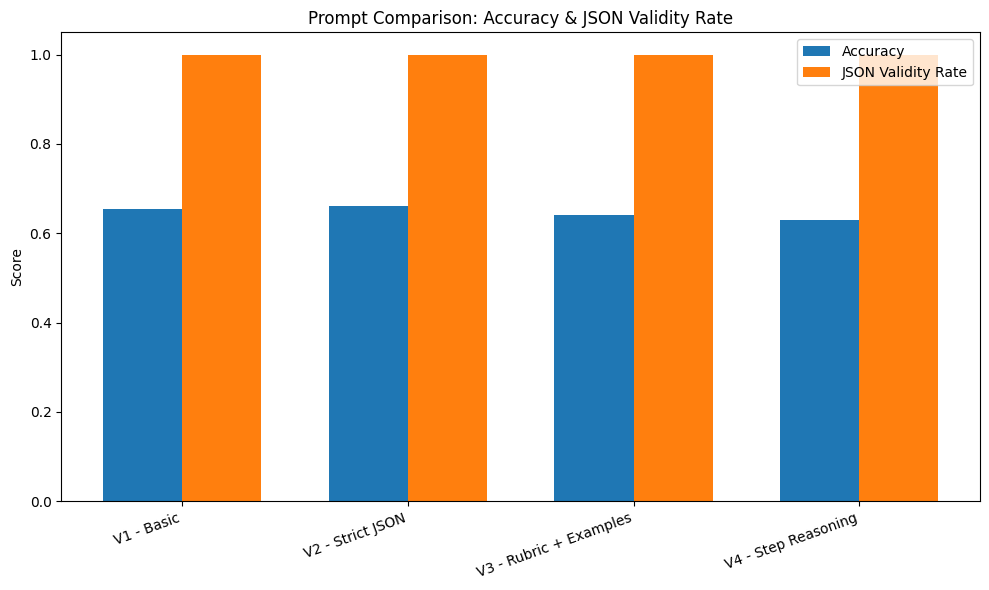

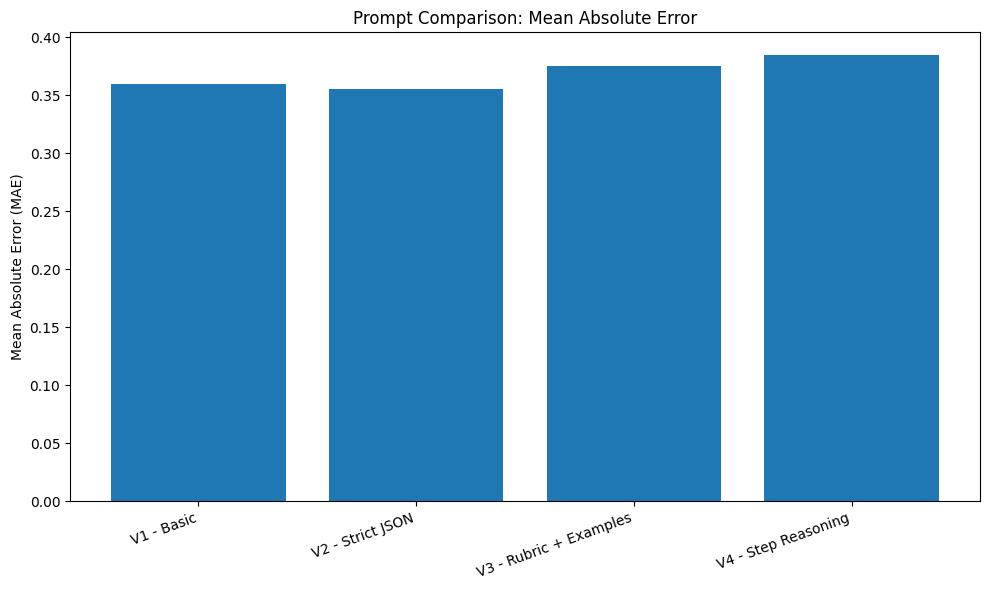

In [ ]:
indices = range(len(comparison_df))
labels = comparison_df["prompt_version"].tolist()

# Plot 1: Accuracy & JSON Validity Rate
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35

acc_values = comparison_df["accuracy"].tolist()
json_values = comparison_df["json_valid_rate"].tolist()

ax.bar([i - bar_width/2 for i in indices], acc_values, width=bar_width, label="Accuracy")
ax.bar([i + bar_width/2 for i in indices], json_values, width=bar_width, label="JSON Validity Rate")

ax.set_xticks(list(indices))
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Score")
ax.set_title("Prompt Comparison: Accuracy & JSON Validity Rate")
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: MAE
fig, ax = plt.subplots(figsize=(10, 6))

mae_values = comparison_df["mae"].tolist()

ax.bar(indices, mae_values)
ax.set_xticks(list(indices))
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Mean Absolute Error (MAE)")
ax.set_title("Prompt Comparison: Mean Absolute Error")
plt.tight_layout()
plt.show()


In [ ]:
# Example: inspect some misclassified reviews for V3
mask_mismatched_v3 = (
    results_v3["json_valid"] &
    results_v3["predicted_stars"].notna() &
    (results_v3["true_stars"] != results_v3["predicted_stars"])
)

errors_v3 = pd.concat([df_sample, results_v3], axis=1)[mask_mismatched_v3]
errors_v3[["text", "true_stars", "predicted_stars", "explanation"]].head(10)


,text,true_stars,predicted_stars,explanation
2,"Every friday, my dad and I eat here. We order ...",3,4,"The review is mostly positive, mentioning good..."
7,Awesome if you like ramen...even awesomer if y...,4,5,"The review is very positive and enthusiastic, ..."
12,Air Jordan! need I say more?,3,5,The phrase 'Air Jordan! need I say more?' expr...
15,So I was pretty excited about this burger join...,2,3,The review expresses mixed feelings: the burge...
16,I really don't consider myself a Neiman's type...,4,2,The review expresses discomfort with the store...
19,This is a quaint little airport which is very ...,5,4,"The review is mostly positive, highlighting th..."
20,Headed back to Lobby's. How I missed this tast...,5,4,"The review is mostly positive, praising the ta..."
24,Someone asked the question in the Yelp talk th...,4,5,"The review is very positive and enthusiastic, ..."
26,Prices are often way too high!,1,2,The review expresses a clear complaint about h...
28,The wood saw is always out of service...\nThe ...,2,3,The review expresses mixed feelings: the wood ...
